In [1]:
# Customer Segmentation project with Kmeans Clustering 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans  
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\COMPUMARTS\OneDrive\Desktop\IBM AI Engineering Certification\Machine Learning with Python\Projects\Mall_Customers.csv')
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
np.random.seed(0)


In [4]:
# Some Ensuring for Cleaning
df = df.dropna()
df = df.drop(columns='Gender')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    ))
])

In [7]:
# using elbow, silhoutte, davies-bouldin methods to evaluate
K = range(2, 11)
inertias = []
silhouette_scores = []
davies_scores = []

for k in K:
    pipeline.set_params(kmeans__n_clusters=k)
    labels = pipeline.fit_predict(X)

    inertias.append(pipeline['kmeans'].inertia_)

    silhouette_scores.append(silhouette_score(pipeline['scaler'].transform(X), labels))

    davies_scores.append(davies_bouldin_score(pipeline['scaler'].transform(X), labels))

print('inertias: ', inertias)
print('silhouette_scores: ', silhouette_scores)
print('davies_scores: ', davies_scores)

inertias:  [269.6910121927639, 157.70400815035947, 108.92131661364355, 65.56840815571681, 55.057348270385994, 44.86475569922557, 37.228187677585886, 32.39226763033116, 29.981897788243693]
silhouette_scores:  [np.float64(0.3212707813918878), np.float64(0.46658474419000145), np.float64(0.4939069237513199), np.float64(0.5546571631111091), np.float64(0.5398800926790663), np.float64(0.5281492781108291), np.float64(0.4552147906587443), np.float64(0.4570853966942764), np.float64(0.4431713026508046)]
davies_scores:  [np.float64(1.266953745774289), np.float64(0.716482156943549), np.float64(0.7095564965521565), np.float64(0.5722356162263352), np.float64(0.6545674732339849), np.float64(0.7147841166477835), np.float64(0.7602174322282717), np.float64(0.7632260748108199), np.float64(0.7934962688817423)]


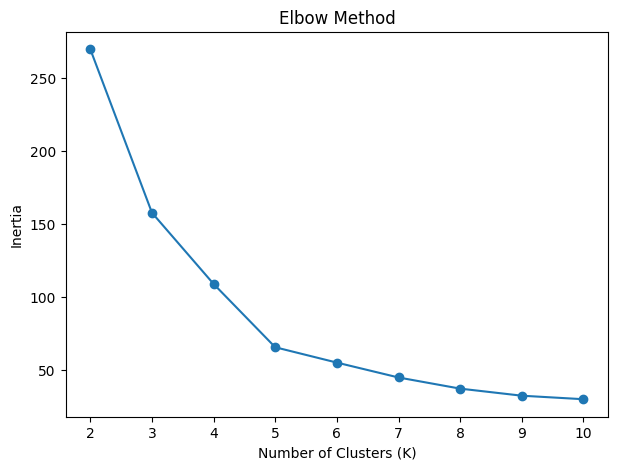

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

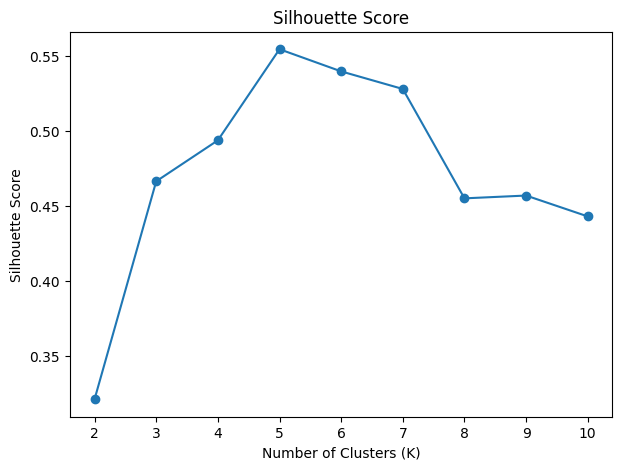

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

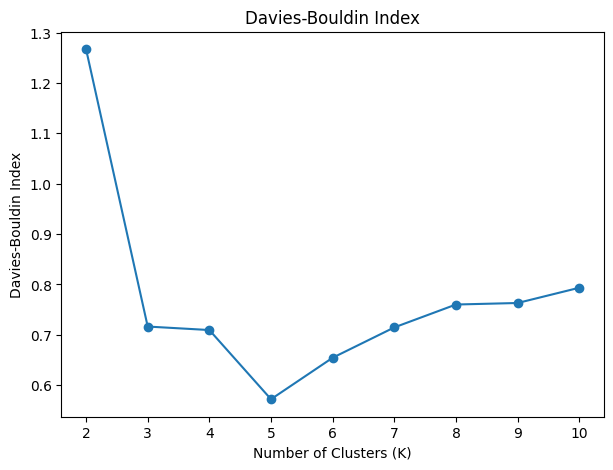

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(K, davies_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index')
plt.show()

In [11]:
pipeline.set_params(kmeans__n_clusters=5)

clusters = pipeline.fit_predict(X)

df['Cluster'] = clusters

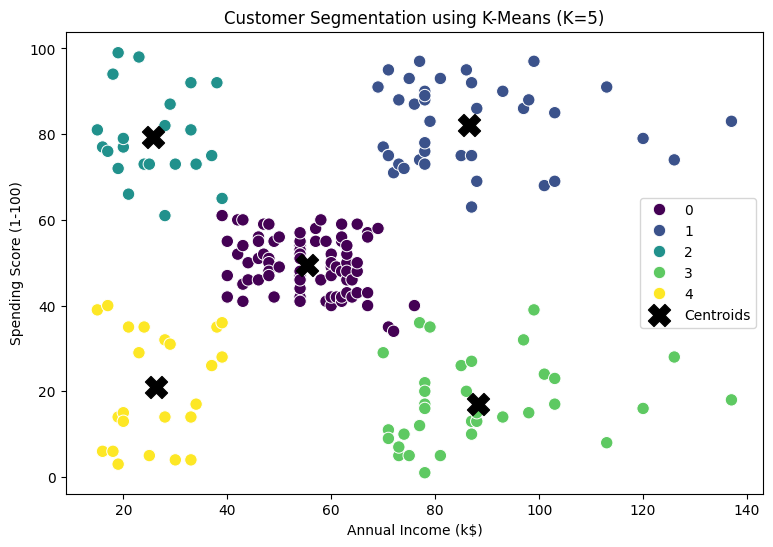

In [12]:
# Get cluster centers in the original scale
centers_scaled = pipeline['kmeans'].cluster_centers_
centers = pipeline['scaler'].inverse_transform(centers_scaled)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=250,
    c='black',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means (K=5)')
plt.legend()

plt.show()

In [13]:
# 0 ->  81 average customers(medium, medium)
# 1 -> 39 Premium Customers
# 2 -> 22 High-value budget shoppers
# 3 -> 35 High income but low-engagement
# 4 -> 23 Low income and engagement customers

In [14]:
cluster_summary = df.groupby('Cluster').agg(
    Customers=('Cluster', 'size'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(2)

print(cluster_summary, "\n")
print(df['Cluster'].value_counts().sort_index())

         Customers  Avg_Income  Avg_Spending
Cluster                                     
0               81       55.30         49.52
1               39       86.54         82.13
2               22       25.73         79.36
3               35       88.20         17.11
4               23       26.30         20.91 

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [15]:
# Using the DBSCAN instead of the KMeans Clustering 

In [16]:
# Testing the values with a pipeline and for loop 

from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

dbscan_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(metric='euclidean'))
])

param_grid = {
    'dbscan__eps': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'dbscan__min_samples': [3, 5, 7, 10]
}


results = []
for params in ParameterGrid(param_grid):

    dbscan_pipeline.set_params(**params)

    labels = dbscan_pipeline.fit_predict(X)

    # Number of clusters, excluding noise (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Number of noise points
    n_noise = sum(labels == -1)

    # Need at least 2 clusters for these metrics
    if n_clusters >= 2:

        X_scaled = dbscan_pipeline['scaler'].transform(X)

        # Exclude noise from metric calculations
        mask = labels != -1

        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        davies = davies_bouldin_score(
            X_scaled[mask],
            labels[mask]
        )

        results.append({
            'eps': params['dbscan__eps'],
            'min_samples': params['dbscan__min_samples'],
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette,
            'davies_bouldin': davies
        })

results_df = pd.DataFrame(results)

results_df.sort_values('silhouette', ascending=False).head(10)
results_df.sort_values('davies_bouldin').head(10)

,eps,min_samples,n_clusters,n_noise,silhouette,davies_bouldin
2,0.2,7,4,100,0.609411,0.366197
5,0.3,7,4,72,0.645159,0.418978
1,0.2,5,7,77,0.585613,0.463725
6,0.3,10,4,88,0.607301,0.470678
10,0.4,10,4,51,0.597195,0.473351
0,0.2,3,13,44,0.469713,0.570370
9,0.4,7,4,20,0.494621,0.578846
4,0.3,5,7,35,0.524328,0.579955
14,0.5,10,4,21,0.510668,0.586769
8,0.4,5,4,15,0.478059,0.591153


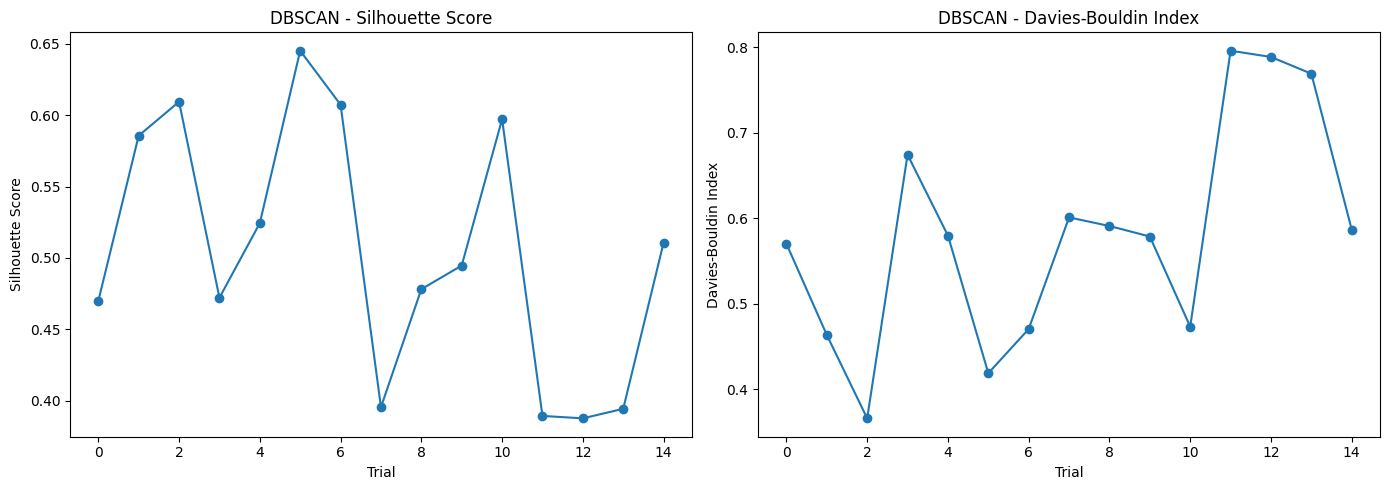

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette
axes[0].plot(
    range(len(results_df)),
    results_df['silhouette'],
    marker='o'
)
axes[0].set_title('DBSCAN - Silhouette Score')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Silhouette Score')

# Davies-Bouldin
axes[1].plot(
    range(len(results_df)),
    results_df['davies_bouldin'],
    marker='o'
)
axes[1].set_title('DBSCAN - Davies-Bouldin Index')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Davies-Bouldin Index')

plt.tight_layout()
plt.show()

In [18]:
# The Actual Model 
final_dbscan_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(
        eps=0.4,
        min_samples=5
    ))
])

dbscan_labels = final_dbscan_pipeline.fit_predict(X)

df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN_Cluster
-1     15
 0    115
 1     11
 2     32
 3     27
Name: count, dtype: int64


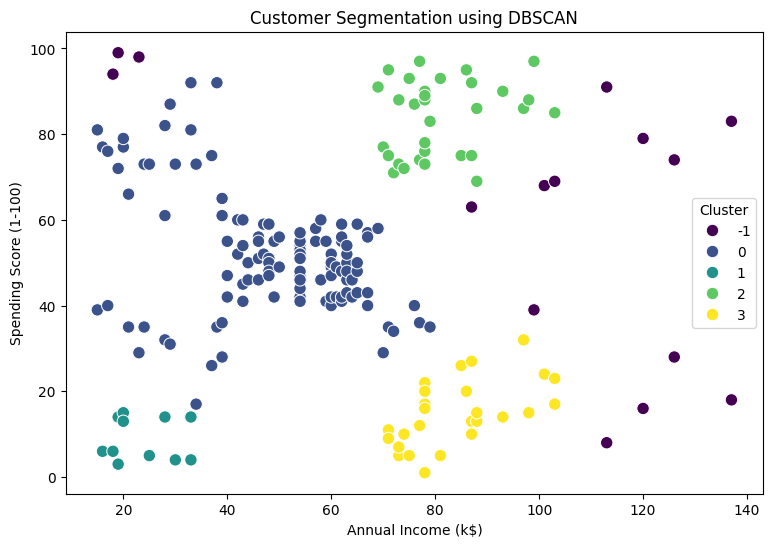

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segmentation using DBSCAN')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.show()

FINAL CUSTOMER SEGMENTATION RESULTS

K-MEANS RESULTS
------------------------------
Number of Clusters : 5
Silhouette Score   : 0.555
Davies-Bouldin     : 0.572

K-MEANS CLUSTER SUMMARY
                Customers  Avg_Income  Avg_Spending
KMeans_Cluster                                     
0                      81       55.30         49.52
1                      39       86.54         82.13
2                      22       25.73         79.36
3                      35       88.20         17.11
4                      23       26.30         20.91


DBSCAN RESULTS
------------------------------
Number of Clusters : 4
Noise Points       : 15
Noise Percentage   : 7.50%
Silhouette Score   : 0.478
Davies-Bouldin     : 0.591

DBSCAN CLUSTER SUMMARY
                Customers  Avg_Income  Avg_Spending
DBSCAN_Cluster                                     
0                     115       48.30         51.73
1                      11       23.73          8.91
2                      32       80.88     

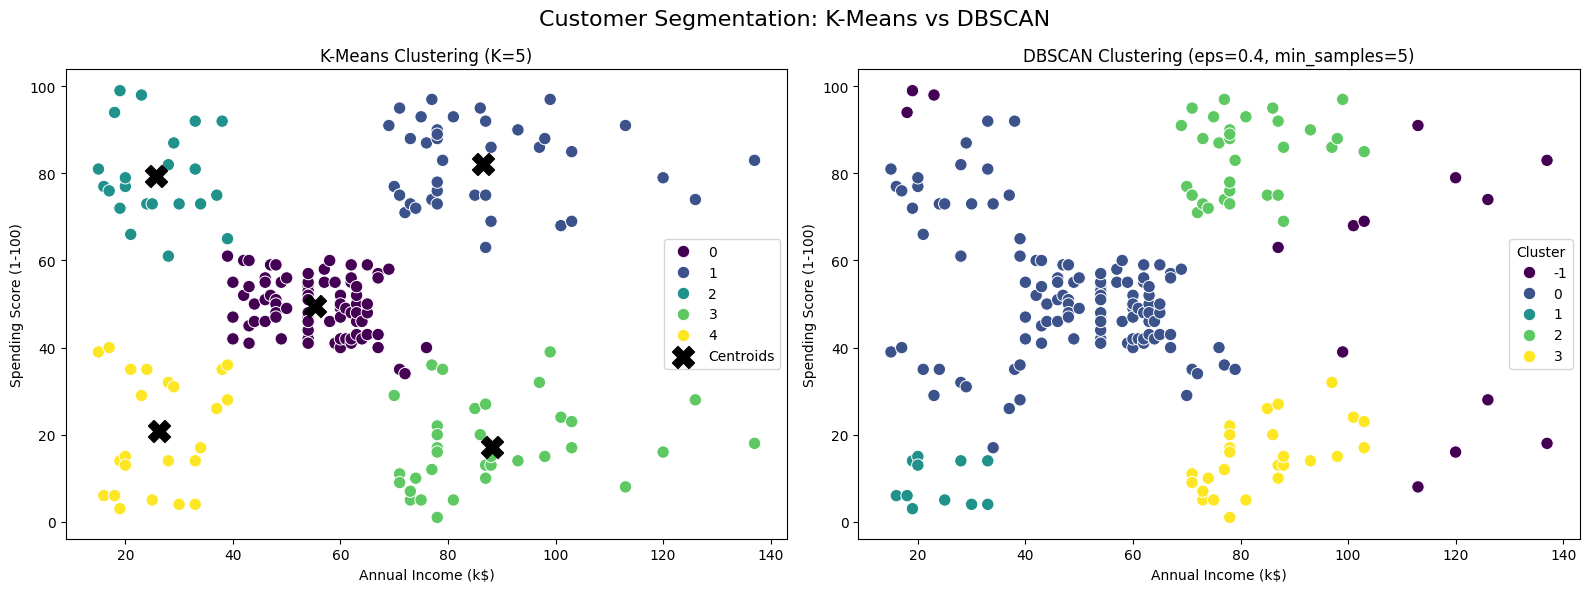

In [20]:
# ============================================================
# FINAL CUSTOMER SEGMENTATION RESULTS
# K-MEANS vs DBSCAN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score, davies_bouldin_score


# ============================================================
# 1. K-MEANS FINAL MODEL
# ============================================================

# Fit final K-Means
pipeline.set_params(kmeans__n_clusters=5)

kmeans_labels = pipeline.fit_predict(X)

# Store labels
df['KMeans_Cluster'] = kmeans_labels

# Scaled data for evaluation
X_scaled_kmeans = pipeline['scaler'].transform(X)


# ============================================================
# 2. K-MEANS METRICS
# ============================================================

kmeans_silhouette = silhouette_score(
    X_scaled_kmeans,
    kmeans_labels
)

kmeans_davies = davies_bouldin_score(
    X_scaled_kmeans,
    kmeans_labels
)

kmeans_n_clusters = len(np.unique(kmeans_labels))


# ============================================================
# 3. K-MEANS SUMMARY
# ============================================================

kmeans_summary = df.groupby('KMeans_Cluster').agg(
    Customers=('KMeans_Cluster', 'size'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(2)


# ============================================================
# 4. DBSCAN FINAL MODEL
# ============================================================

dbscan_labels = final_dbscan_pipeline.fit_predict(X)

df['DBSCAN_Cluster'] = dbscan_labels

# Scaled data
X_scaled_dbscan = final_dbscan_pipeline['scaler'].transform(X)

# Remove noise (-1) for evaluation
dbscan_mask = dbscan_labels != -1

# Number of actual clusters (excluding -1)
dbscan_n_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
dbscan_n_noise = np.sum(dbscan_labels == -1)


# ============================================================
# 5. DBSCAN METRICS
# ============================================================

if dbscan_n_clusters >= 2:

    dbscan_silhouette = silhouette_score(
        X_scaled_dbscan[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )

    dbscan_davies = davies_bouldin_score(
        X_scaled_dbscan[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )

else:
    dbscan_silhouette = np.nan
    dbscan_davies = np.nan


# ============================================================
# 6. DBSCAN SUMMARY
# ============================================================

# Exclude noise from the cluster summary
dbscan_summary = df[
    df['DBSCAN_Cluster'] != -1
].groupby('DBSCAN_Cluster').agg(
    Customers=('DBSCAN_Cluster', 'size'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(2)


# ============================================================
# 7. PRINT FINAL COMPARISON
# ============================================================

print("=" * 60)
print("FINAL CUSTOMER SEGMENTATION RESULTS")
print("=" * 60)

print("\nK-MEANS RESULTS")
print("-" * 30)

print(f"Number of Clusters : {kmeans_n_clusters}")
print(f"Silhouette Score   : {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin     : {kmeans_davies:.3f}")

print("\nK-MEANS CLUSTER SUMMARY")
print(kmeans_summary)


print("\n" + "=" * 60)

print("\nDBSCAN RESULTS")
print("-" * 30)

print(f"Number of Clusters : {dbscan_n_clusters}")
print(f"Noise Points       : {dbscan_n_noise}")
print(f"Noise Percentage   : {(dbscan_n_noise / len(X)) * 100:.2f}%")
print(f"Silhouette Score   : {dbscan_silhouette:.3f}")
print(f"Davies-Bouldin     : {dbscan_davies:.3f}")

print("\nDBSCAN CLUSTER SUMMARY")
print(dbscan_summary)


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN'],
    'Clusters': [
        kmeans_n_clusters,
        dbscan_n_clusters
    ],
    'Noise Points': [
        0,
        dbscan_n_noise
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        dbscan_silhouette
    ],
    'Davies-Bouldin': [
        kmeans_davies,
        dbscan_davies
    ]
})

print("\n" + "=" * 60)
print("K-MEANS vs DBSCAN")
print("=" * 60)

print(comparison.round(3))


# ============================================================
# 9. TWO CLUSTERING GRAPHS SIDE-BY-SIDE
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)


# -------------------------
# K-MEANS GRAPH
# -------------------------

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='viridis',
    s=80,
    ax=axes[0]
)

axes[0].set_title(
    f'K-Means Clustering (K={kmeans_n_clusters})'
)

axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')


# Add K-Means centroids
centers_scaled = pipeline['kmeans'].cluster_centers_

centers_original = pipeline[
    'scaler'
].inverse_transform(centers_scaled)

axes[0].scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker='X',
    s=250,
    c='black',
    label='Centroids'
)

axes[0].legend()


# -------------------------
# DBSCAN GRAPH
# -------------------------

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    palette='viridis',
    s=80,
    ax=axes[1]
)

axes[1].set_title(
    f'DBSCAN Clustering '
    f'(eps=0.4, min_samples=5)'
)

axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

axes[1].legend(title='Cluster')


# ============================================================
# FINAL DISPLAY
# ============================================================

plt.suptitle(
    'Customer Segmentation: K-Means vs DBSCAN',
    fontsize=16
)

plt.tight_layout()

plt.show()

In [22]:
import joblib

# Save the trained K-Means pipeline
joblib.dump(pipeline, "customer_segmentation_model.pkl")

print("Model saved successfully!")

Model saved successfully!
